Cellule 1 : Importations et Configuration

In [31]:
import os
import webbrowser
import folium
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from lightgbm import LGBMClassifier
import warnings

# Configuration pour un affichage propre
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

Cellule 2 : 1. Compréhension et Exploration (EDA)

In [32]:
# Chargement et analyse de la structure
df = pd.read_csv("dataset/geo_stabilite_terrain_data.csv")

# Affichage des 10 premières lignes (Visualisation sans print pour le formatage)
display(df.head(10))

# Statistiques et types de données
print(f"Dimensions du dataset : {df.shape}")
df.info()
display(df.describe())

# Identification des valeurs manquantes avant traitement
print("Valeurs manquantes initiales :")
print(df.isnull().sum())

,pente_pct,altitude_m,texture_sol,humidite_sol,distance_faille_km,couverture_vegetale,longitude,latitude,zone_id,stabilite_terrain,indice_geotech_labo
0,14.981605,640.304544,0.488496,42.206608,6.767225,0.707993,-6.258685,34.429771,427,Moyennement_stable,NaN
1,38.028572,845.545277,0.401887,26.103519,0.120083,0.267965,-6.548971,34.860529,344,MOY_STABLE,NaN
2,29.279758,622.540410,0.153691,15.356171,0.988193,0.204539,-6.202923,34.569859,507,moyennement stable,NaN
3,23.946339,522.707003,0.572607,7.113067,10.581034,0.526851,-5.632015,35.252465,341,Moyennement_stable,NaN
4,6.240746,622.013551,0.277013,34.043394,NaN,0.310989,-6.538227,35.193357,321,Moyennement_stable,NaN
5,6.239781,697.793645,0.921308,9.852120,NaN,0.616015,-6.314916,34.452766,484,Stable,NaN
6,2.323344,608.794813,0.583191,17.111005,11.044456,0.156145,-5.681898,35.403913,425,MOY_STABLE,NaN
7,34.647046,607.306504,0.592840,NaN,3.284669,0.639447,-5.582553,34.698492,456,moyennement stable,NaN
8,24.044600,473.641496,0.354925,27.576664,4.477373,0.304967,-6.008086,34.918672,484,Moyennement_stable,NaN
9,28.322903,480.677835,0.051989,29.023328,6.848611,0.050219,-5.692503,35.201520,364,Moyennement_stable,NaN


Dimensions du dataset : (1549, 11)
<class 'pandas.DataFrame'>
RangeIndex: 1549 entries, 0 to 1548
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pente_pct            1455 non-null   float64
 1   altitude_m           1501 non-null   float64
 2   texture_sol          1417 non-null   float64
 3   humidite_sol         1443 non-null   float64
 4   distance_faille_km   1486 non-null   float64
 5   couverture_vegetale  1455 non-null   float64
 6   longitude            1549 non-null   float64
 7   latitude             1549 non-null   float64
 8   zone_id              1549 non-null   int64  
 9   stabilite_terrain    1548 non-null   str    
 10  indice_geotech_labo  156 non-null    float64
dtypes: float64(9), int64(1), str(1)
memory usage: 133.2 KB


,pente_pct,altitude_m,texture_sol,humidite_sol,distance_faille_km,couverture_vegetale,longitude,latitude,zone_id,indice_geotech_labo
count,1455.000000,1501.000000,1417.000000,1443.000000,1486.000000,1455.000000,1549.000000,1549.000000,1549.000000,156.000000
mean,19.914196,608.526967,0.490783,24.753442,5.876987,0.488085,-5.939485,34.995105,362.592640,0.551224
std,11.727497,176.181677,0.287108,11.592068,3.414436,0.252860,0.373466,0.351013,92.572292,0.134978
min,0.185281,70.730046,0.000031,5.156735,0.052880,0.050048,-6.599687,34.400189,200.000000,0.171521
25%,9.516407,486.732589,0.237479,14.741637,2.974439,0.276923,-6.264394,34.688642,283.000000,0.466280
50%,20.136691,606.882839,0.483181,24.640791,5.804080,0.479078,-5.933843,34.979046,362.000000,0.538526
75%,29.992246,724.725352,0.739469,34.700119,8.769188,0.697907,-5.615704,35.309189,442.000000,0.636614
max,39.988707,1174.759362,0.999558,44.978427,11.990527,0.948756,-5.300425,35.599202,519.000000,0.886169


Valeurs manquantes initiales :
pente_pct                94
altitude_m               48
texture_sol             132
humidite_sol            106
distance_faille_km       63
couverture_vegetale      94
longitude                 0
latitude                  0
zone_id                   0
stabilite_terrain         1
indice_geotech_labo    1393
dtype: int64


Cellule 3 : 2. Visualisation (Avant Prétraitement)

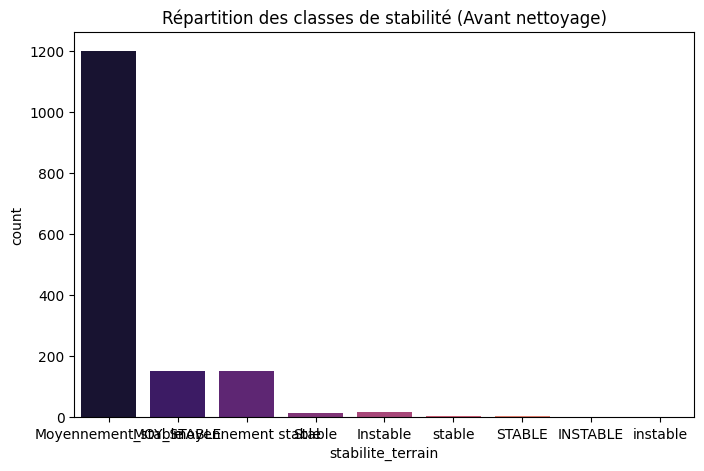

In [33]:
# Visualisation de la distribution de la cible pour détecter les déséquilibres
plt.figure(figsize=(8, 5))
sns.countplot(x='stabilite_terrain', data=df, palette='magma')
plt.title("Répartition des classes de stabilité (Avant nettoyage)")
plt.show()

Cellule 4 : 3. Prétraitement des données

In [34]:
# --- Harmonisation des modalités ---
df["stabilite_terrain"] = df["stabilite_terrain"].str.lower().str.strip()
df["stabilite_terrain"] = df["stabilite_terrain"].replace({
    "moyennement_stable": "moyen",
    "moyennement stable": "moyen",
    "moy_stable": "moyen"
})

# --- Traitement des valeurs manquantes et colonnes ---
# Justification : suppression d'indice_geotech_labo car trop de données manquantes
df.drop(columns="indice_geotech_labo", inplace=True, errors='ignore')

# Imputation par moyenne/mode
df["pente_pct"] = df["pente_pct"].fillna(df["pente_pct"].mean())
df["altitude_m"] = df["altitude_m"].fillna(df["altitude_m"].mode()[0])
df["texture_sol"] = df["texture_sol"].fillna(df["texture_sol"].mean())
df["humidite_sol"] = df["humidite_sol"].fillna(df["humidite_sol"].mean())
df["distance_faille_km"] = df["distance_faille_km"].fillna(df["distance_faille_km"].mean())
df["couverture_vegetale"] = df["couverture_vegetale"].fillna(df["couverture_vegetale"].mean())

# Suppression des lignes résiduelles problématiques
df = df.dropna(subset=["stabilite_terrain"])
df = df.dropna(how = "any")

# Détection et suppression des doublons
df = df.drop_duplicates()

print("Prétraitement terminé. Valeurs manquantes restantes :", df.isnull().sum().sum())

Prétraitement terminé. Valeurs manquantes restantes : 0


Cellule 5 : 4. Modélisation (LightGBM)

In [35]:
# --- Séparation Features/Target ---
# Note : Les variables spatiales (lat/long) sont exclues conformément aux règles
X = df[["pente_pct", "altitude_m", "texture_sol", "humidite_sol", "distance_faille_km", "couverture_vegetale"]]
Y = df["stabilite_terrain"]

# --- Standardisation ---
stand = StandardScaler()
X_stand = stand.fit_transform(X)

# --- Train/Test Split ---
X_train, X_test, Y_train, Y_test = train_test_split(X_stand, Y, test_size=0.25, random_state=42)

# --- Implémentation du modèle LGBM ---
model_lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model_lgbm.fit(X_train, Y_train)
Y_pred = model_lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1158, number of used features: 6
[LightGBM] [Info] Start training from score -4.489500
[LightGBM] [Info] Start training from score -0.027135
[LightGBM] [Info] Start training from score -4.164078
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

Cellule 6 : 5. Évaluation et Visualisation Finale

----------- Évaluation LightGBM ------------
Accuracy : 0.9897

Rapport de classification :
              precision    recall  f1-score   support

    instable       1.00      0.67      0.80         6
       moyen       0.99      1.00      0.99       374
      stable       1.00      0.71      0.83         7

    accuracy                           0.99       387
   macro avg       1.00      0.79      0.88       387
weighted avg       0.99      0.99      0.99       387



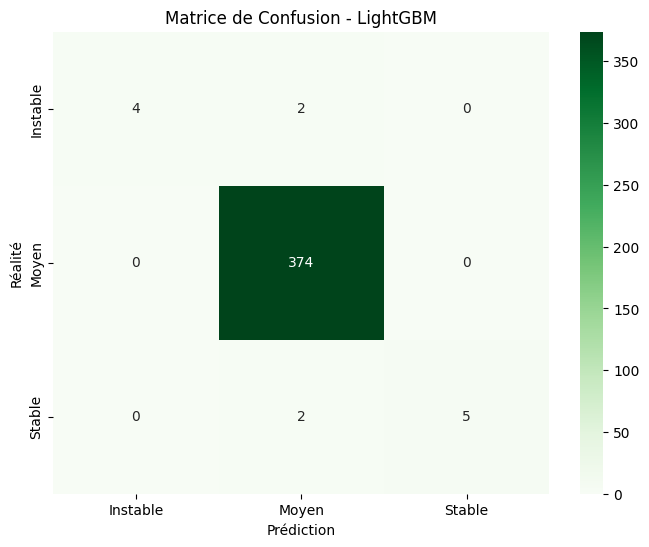

In [36]:
# --- Métriques de performance ---
print("----------- Évaluation LightGBM ------------")
print(f"Accuracy : {accuracy_score(Y_test, Y_pred):.4f}")
print("\nRapport de classification :")
print(classification_report(Y_test, Y_pred))

# --- Matrice de confusion ---
conf_matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Instable', 'Moyen', 'Stable'],
            yticklabels=['Instable', 'Moyen', 'Stable'])
plt.title('Matrice de Confusion - LightGBM')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

Cellule 7 : Cartographie Spatiale

In [37]:
# Visualisation géographique des prédictions
df["prediction_lgbm"] = model_lgbm.predict(X_stand)
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=8)

# S'assurer que les clés du dictionnaire correspondent exactement aux prédictions
colors = {
    "instable": "red", 
    "moyen": "orange", 
    "stable": "green"
}

# Création de la carte centrée sur la moyenne des coordonnées
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=8)

for _, row in df.iterrows():
    # On récupère la prédiction en minuscules pour correspondre au dictionnaire
    pred = str(row["prediction_lgbm"]).lower()
    
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        color=colors.get(pred, "black"), # "black" si la classe est inconnue
        fill=True,
        fill_opacity=0.8,
        # Bonus : Ajouter la valeur réelle pour comparer visuellement sur la carte
        popup=(f"<b>Zone ID:</b> {row['zone_id']}<br>"
               f"<b>Réel:</b> {row['stabilite_terrain']}<br>"
               f"<b>Prédit:</b> {row['prediction_lgbm']}")
    ).add_to(m)

# Sauvegarde et ouverture
m.save("carte_lightgbm.html")
print("Carte générée avec succès : Vérifiez les zones rouges pour les risques de glissement.")
webbrowser.open(os.path.abspath("carte_lightgbm.html"))

Carte générée avec succès : Vérifiez les zones rouges pour les risques de glissement.


True